In [2]:
import matplotlib.pyplot as plt
import cv2

IMG_PATH_BACKGROUND = 'images/background.png'
IMG_PATH_THUMB = 'images/thumb.png'

img_bg = cv2.imread(IMG_PATH_BACKGROUND)
img_thumb = cv2.imread(IMG_PATH_THUMB)

img_bg_gray = cv2.cvtColor(img_bg, cv2.COLOR_BGR2GRAY)
img_thumb_gray = cv2.cvtColor(img_thumb, cv2.COLOR_BGR2GRAY)

img_bg_gray = cv2.GaussianBlur(img_bg_gray, (5, 5), 0)
img_thumb_gray = cv2.GaussianBlur(img_thumb_gray, (5, 5), 0)

img_substract = cv2.absdiff(img_bg, img_thumb)
img_gray = cv2.cvtColor(img_substract, cv2.COLOR_BGR2GRAY)
#img_gray = cv2.GaussianBlur(img_gray, (5, 5), 0)

#THRESHOLD 100 to 255
img_thresh = cv2.threshold(img_gray, 20, 255, cv2.THRESH_BINARY)

plt.imshow(img_thresh[1], cmap='gray')
plt.title('Binary Thresholding')

ModuleNotFoundError: No module named 'matplotlib'

(np.float64(-0.5), np.float64(899.5), np.float64(1599.5), np.float64(-0.5))

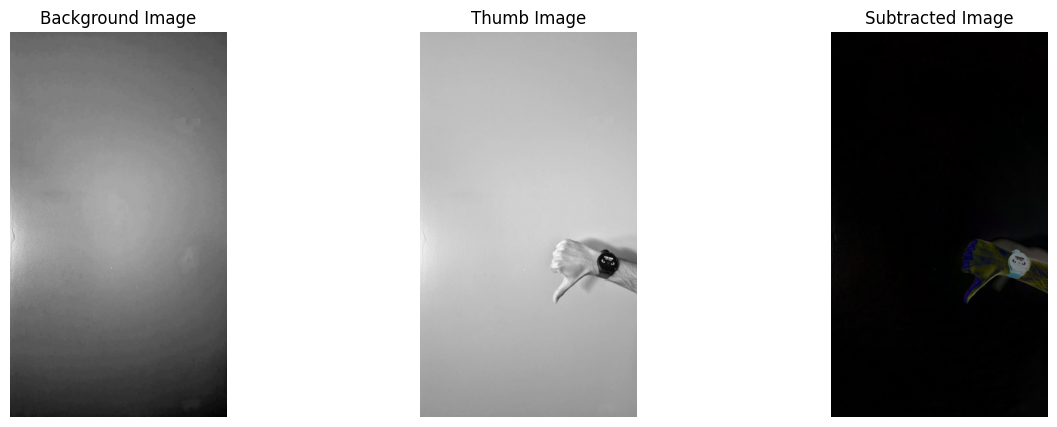

In [25]:
#plot images
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_bg_gray, cmap='gray')
plt.title('Background Image')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(img_thumb_gray, cmap='gray')
plt.title('Thumb Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_substract, cmap='gray')
plt.title('Subtracted Image')
plt.axis('off')


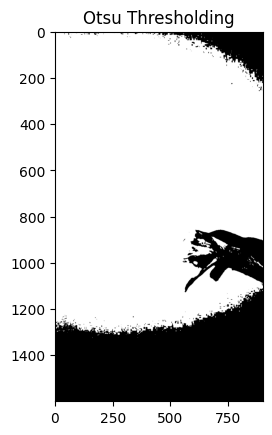

In [27]:
img_thresh_2 = cv2.threshold(img_thumb_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(img_thresh_2[1], cmap='gray')
plt.title('Otsu Thresholding')
plt.show()

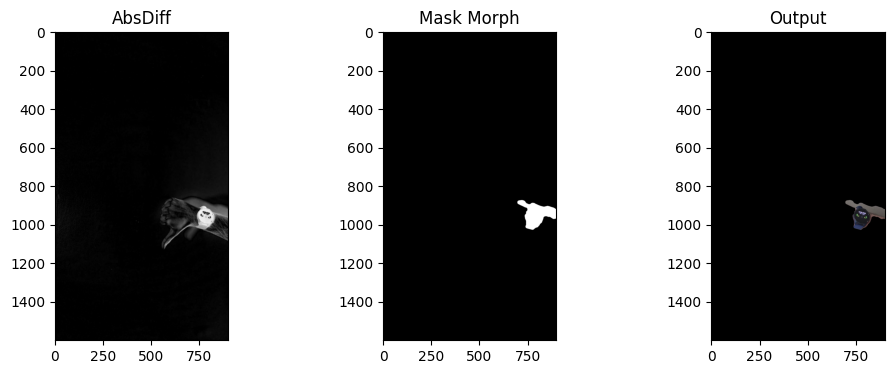

In [1]:
import numpy as np

def quitar_sombra_ajustado(frame, background):
    # 1. Convertir ambos a HSV
    hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    hsv_bg = cv2.cvtColor(background, cv2.COLOR_BGR2HSV)
    
    # 2. Calcular la diferencia absoluta en cada canal
    # El canal H (0) es el más robusto ante sombras
    diff_h = cv2.absdiff(hsv_frame[:,:,0], hsv_bg[:,:,0])
    diff_s = cv2.absdiff(hsv_frame[:,:,1], hsv_bg[:,:,1])
    diff_v = cv2.absdiff(hsv_frame[:,:,2], hsv_bg[:,:,2])
    
    # 3. Umbralización inteligente:
    # La sombra cambia mucho el valor (V) pero poco el tono (H).
    # Solo queremos píxeles donde el color (H) o la saturación (S) hayan cambiado significativamente.
    _, mask_h = cv2.threshold(diff_h, 15, 255, cv2.THRESH_BINARY)
    _, mask_s = cv2.threshold(diff_s, 30, 255, cv2.THRESH_BINARY)
    
    # Combinamos: si cambió el tono O la saturación, es la mano.
    # Ignoramos cambios que solo sean de brillo (sombras).
    mask_final = cv2.bitwise_or(mask_h, mask_s)
    
    # 4. Limpieza Morfológica (Crucial para tu imagen)
    kernel = np.ones((5, 5), np.uint8)
    # Elimina el ruido disperso (puntos pequeños)
    mask_final = cv2.morphologyEx(mask_final, cv2.MORPH_OPEN, kernel)
    # Rellena los huecos dentro de la mano y el reloj
    mask_final = cv2.morphologyEx(mask_final, cv2.MORPH_CLOSE, kernel)
    
    return mask_final

# --- Lógica de prueba ---
# Asumiendo que ya tienes capturado el 'background' (fondo vacío) 
background = cv2.imread('images/background.png')
frame = cv2.imread('images/thumb.png')

mascara = quitar_sombra_ajustado(frame, background)
cv2.imshow('Mano Limpia', mascara)


NameError: name 'cv2' is not defined